# Logical Fallacy Detection - Progress 3
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Progress 3:** Three model families with two text representations each (6 models total):
- **Models:** Linear SVC, Complement Naive Bayes, Logistic Regression
- **Text Representation:** TF-IDF and Word2Vec averaged document vectors
- **Comparison:** All Progress 3 models + Progress 2 models (TF-IDF and Word2Vec)

**Citation:**
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Import Libraries

In [1]:
import json
import re
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
    print(f"Running on Kaggle (dataset: {DATA_DIR})")
else:
    DATA_DIR = 'data'   
    print("Running locally")

# Load train data
file_path = os.path.join(DATA_DIR, 'train.json')
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    
records = []
for article in raw_data:
    for comment in article['comments']:
        records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df = pd.DataFrame(records)

# Load test data
with open(os.path.join(DATA_DIR, 'test.json'), 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total train comments: {len(df)}")
print(f"Total test comments: {len(df_test)}")
print(f"\nDistribusi label fallacy (train):")
print(df['fallacy'].value_counts())

Running locally
Total train comments: 5370
Total test comments: 798

Distribusi label fallacy (train):
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Clean raw text."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['comment'].apply(clean_text)
df_test['cleaned'] = df_test['comment'].apply(clean_text)

print("Text cleaning complete.")

Text cleaning complete.


## 3. Tokenization

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)

print("Tokenization complete.")

Tokenization complete.


## 4. Stopword Removal & Lemmatization

In [5]:
fallacy_indicators = {
    'everyone', 'always', 'never', 'must', 'should', 'all', 'every',
    'only', 'just', 'no', 'nothing', 'everything', 'most', 'any',
    'either', 'or', 'neither', 'nor', 'both', 'very', 'too',
}
stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

print("Lemmatization complete.")

Lemmatization complete.


## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority (350 samples)
  1 → appeal to majority (383 samples)
  2 → appeal to nature (412 samples)
  3 → appeal to tradition (401 samples)
  4 → appeal to worse problems (421 samples)
  5 → false dilemma (391 samples)
  6 → hasty generalization (379 samples)
  7 → none (2202 samples)
  8 → slippery slope (431 samples)


## 6. Train/Validation/Test Split (80/10/10)

In [7]:
df_train, df_val = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

print(f"Train set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

Train set size: 4564
Validation set size: 806
Test set size: 798


---
## 7. Text Representation: TF-IDF + Word2Vec

In [8]:
# Shared helper for Word2Vec document embeddings
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# TF-IDF for SVC and ComplementNB
tfidf_vectorizer = TfidfVectorizer(
    analyzer='word',
    max_features=12000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    lowercase=False,
    token_pattern=r'(?u)\b\w+\b',
)
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['processed_text'])
X_val_tfidf = tfidf_vectorizer.transform(df_val['processed_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])

# Dedicated TF-IDF for Logistic Regression (same as previous setup)
tfidf_vectorizer_logreg = TfidfVectorizer(
    analyzer='word',
    max_features=25000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.99,
    lowercase=False,
    token_pattern=r'(?u)\b\w+\b',
)
X_train_logreg = tfidf_vectorizer_logreg.fit_transform(df_train['processed_text'])
X_val_logreg = tfidf_vectorizer_logreg.transform(df_val['processed_text'])
X_test_logreg = tfidf_vectorizer_logreg.transform(df_test['processed_text'])

# Train Word2Vec once and reuse for all W2V models
print("Training Word2Vec representation for Progress 3...")
w2v_model_p3 = Word2Vec(
    sentences=df_train['lemmatized'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    sg=1
)
X_train_w2v_p3 = np.array([document_vector(tokens, w2v_model_p3) for tokens in df_train['lemmatized']])
X_val_w2v_p3 = np.array([document_vector(tokens, w2v_model_p3) for tokens in df_val['lemmatized']])
X_test_w2v_p3 = np.array([document_vector(tokens, w2v_model_p3) for tokens in df_test['lemmatized']])

print("Representation setup complete.")
print(f"TF-IDF (SVC/CNB) shapes: Train={X_train_tfidf.shape}, Val={X_val_tfidf.shape}, Test={X_test_tfidf.shape}")
print(f"TF-IDF (LogReg) shapes: Train={X_train_logreg.shape}, Val={X_val_logreg.shape}, Test={X_test_logreg.shape}")
print(f"Word2Vec vocabulary size: {len(w2v_model_p3.wv)}")
print(f"W2V shapes: Train={X_train_w2v_p3.shape}, Val={X_val_w2v_p3.shape}, Test={X_test_w2v_p3.shape}")

Training Word2Vec representation for Progress 3...
Representation setup complete.
TF-IDF (SVC/CNB) shapes: Train=(4564, 12000), Val=(806, 12000), Test=(798, 12000)
TF-IDF (LogReg) shapes: Train=(4564, 25000), Val=(806, 25000), Test=(798, 25000)
Word2Vec vocabulary size: 6180
W2V shapes: Train=(4564, 100), Val=(806, 100), Test=(798, 100)


In [9]:
y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values

---
## 8. Load Progress 2 Models for Comparison

In [10]:
# document_vector is defined in Section 7 and reused here for P2 evaluation
print("Document vector helper is ready.")

Document vector helper is ready.


In [11]:
# Load Progress 2 models
p2_logreg_tfidf = joblib.load('models/progress_2/logistic_regression_tfidf.joblib')
p2_logreg_w2v = joblib.load('models/progress_2/logistic_regression_w2v.joblib')
p2_tfidf_vectorizer = joblib.load('models/progress_2/tfidf_vectorizer.joblib')
p2_w2v_model = joblib.load('models/progress_2/word2vec_model.joblib')
p2_info = joblib.load('models/progress_2/preprocessing_info.joblib')

print("Progress 2 models loaded!")
print(f"  LogReg + TF-IDF   → F1: {p2_info['models']['logreg_tfidf']['f1_weighted']:.4f}")
print(f"  LogReg + Word2Vec → F1: {p2_info['models']['logreg_w2v']['f1_weighted']:.4f}")

Progress 2 models loaded!
  LogReg + TF-IDF   → F1: 0.6830
  LogReg + Word2Vec → F1: 0.5165


In [12]:
# Prepare P2 validation and test data using P2's vectorizers
X_val_tfidf_p2 = p2_tfidf_vectorizer.transform(df_val['processed_text'])
X_test_tfidf_p2 = p2_tfidf_vectorizer.transform(df_test['processed_text'])
X_val_w2v_p2 = np.array([document_vector(tokens, p2_w2v_model) for tokens in df_val['lemmatized']])
X_test_w2v_p2 = np.array([document_vector(tokens, p2_w2v_model) for tokens in df_test['lemmatized']])

# Evaluate P2 models on validation and test data
y_val_pred_p2_logreg_tfidf = p2_logreg_tfidf.predict(X_val_tfidf_p2)
y_val_pred_p2_logreg_w2v = p2_logreg_w2v.predict(X_val_w2v_p2)
y_pred_p2_logreg_tfidf = p2_logreg_tfidf.predict(X_test_tfidf_p2)
y_pred_p2_logreg_w2v = p2_logreg_w2v.predict(X_test_w2v_p2)

print("Progress 2 models evaluated on validation and test data.")

Progress 2 models evaluated on validation and test data.


---
## 9. Model 1: Linear SVC (TF-IDF + Word2Vec)

In [13]:
# TF-IDF variant
model_svc_tfidf = LinearSVC(
    C=3.0,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
model_svc_tfidf.fit(X_train_tfidf, y_train)
y_val_pred_svc_tfidf = model_svc_tfidf.predict(X_val_tfidf)
y_test_pred_svc_tfidf = model_svc_tfidf.predict(X_test_tfidf)

val_f1_svc_tfidf = f1_score(y_val, y_val_pred_svc_tfidf, average='weighted')
test_acc_svc_tfidf = accuracy_score(y_test, y_test_pred_svc_tfidf)
test_f1_svc_tfidf = f1_score(y_test, y_test_pred_svc_tfidf, average='weighted')

# Word2Vec variant
model_svc_w2v = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
model_svc_w2v.fit(X_train_w2v_p3, y_train)
y_val_pred_svc_w2v = model_svc_w2v.predict(X_val_w2v_p3)
y_test_pred_svc_w2v = model_svc_w2v.predict(X_test_w2v_p3)

val_f1_svc_w2v = f1_score(y_val, y_val_pred_svc_w2v, average='weighted')
test_acc_svc_w2v = accuracy_score(y_test, y_test_pred_svc_w2v)
test_f1_svc_w2v = f1_score(y_test, y_test_pred_svc_w2v, average='weighted')

print("Linear SVC complete for both representations.")
print(f"TF-IDF  -> Val F1: {val_f1_svc_tfidf:.4f} | Test Acc: {test_acc_svc_tfidf:.4f} | Test F1: {test_f1_svc_tfidf:.4f}")
print(f"W2V     -> Val F1: {val_f1_svc_w2v:.4f} | Test Acc: {test_acc_svc_w2v:.4f} | Test F1: {test_f1_svc_w2v:.4f}")

Linear SVC complete for both representations.
TF-IDF  -> Val F1: 0.6602 | Test Acc: 0.6767 | Test F1: 0.6715
W2V     -> Val F1: 0.5394 | Test Acc: 0.5602 | Test F1: 0.5544


---
## 10. Model 2: Complement Naive Bayes (TF-IDF + Word2Vec)

In [14]:
# TF-IDF variant
model_cnb_tfidf = ComplementNB(alpha=0.5)
model_cnb_tfidf.fit(X_train_tfidf, y_train)
y_val_pred_cnb_tfidf = model_cnb_tfidf.predict(X_val_tfidf)
y_test_pred_cnb_tfidf = model_cnb_tfidf.predict(X_test_tfidf)

val_f1_cnb_tfidf = f1_score(y_val, y_val_pred_cnb_tfidf, average='weighted')
test_acc_cnb_tfidf = accuracy_score(y_test, y_test_pred_cnb_tfidf)
test_f1_cnb_tfidf = f1_score(y_test, y_test_pred_cnb_tfidf, average='weighted')

# Word2Vec variant (ComplementNB needs non-negative values)
cnb_scaler = MinMaxScaler()
X_train_w2v_cnb = cnb_scaler.fit_transform(X_train_w2v_p3)
X_val_w2v_cnb = cnb_scaler.transform(X_val_w2v_p3)
X_test_w2v_cnb = cnb_scaler.transform(X_test_w2v_p3)

model_cnb_w2v = ComplementNB(alpha=0.5)
model_cnb_w2v.fit(X_train_w2v_cnb, y_train)
y_val_pred_cnb_w2v = model_cnb_w2v.predict(X_val_w2v_cnb)
y_test_pred_cnb_w2v = model_cnb_w2v.predict(X_test_w2v_cnb)

val_f1_cnb_w2v = f1_score(y_val, y_val_pred_cnb_w2v, average='weighted')
test_acc_cnb_w2v = accuracy_score(y_test, y_test_pred_cnb_w2v)
test_f1_cnb_w2v = f1_score(y_test, y_test_pred_cnb_w2v, average='weighted')

print("ComplementNB complete for both representations.")
print(f"TF-IDF  -> Val F1: {val_f1_cnb_tfidf:.4f} | Test Acc: {test_acc_cnb_tfidf:.4f} | Test F1: {test_f1_cnb_tfidf:.4f}")
print(f"W2V     -> Val F1: {val_f1_cnb_w2v:.4f} | Test Acc: {test_acc_cnb_w2v:.4f} | Test F1: {test_f1_cnb_w2v:.4f}")

ComplementNB complete for both representations.
TF-IDF  -> Val F1: 0.6427 | Test Acc: 0.6316 | Test F1: 0.6186
W2V     -> Val F1: 0.4361 | Test Acc: 0.4887 | Test F1: 0.4709


---
## 11. Model 3: Logistic Regression (TF-IDF + Word2Vec)

In [15]:
# TF-IDF variant
model_logreg_tfidf = LogisticRegression(
    C=4.0,
    max_iter=4000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
model_logreg_tfidf.fit(X_train_logreg, y_train)
y_val_pred_logreg_tfidf = model_logreg_tfidf.predict(X_val_logreg)
y_test_pred_logreg_tfidf = model_logreg_tfidf.predict(X_test_logreg)

val_f1_logreg_tfidf = f1_score(y_val, y_val_pred_logreg_tfidf, average='weighted')
test_acc_logreg_tfidf = accuracy_score(y_test, y_test_pred_logreg_tfidf)
test_f1_logreg_tfidf = f1_score(y_test, y_test_pred_logreg_tfidf, average='weighted')

# Word2Vec variant
model_logreg_w2v_p3 = LogisticRegression(
    C=1.5,
    max_iter=3000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
model_logreg_w2v_p3.fit(X_train_w2v_p3, y_train)
y_val_pred_logreg_w2v = model_logreg_w2v_p3.predict(X_val_w2v_p3)
y_test_pred_logreg_w2v = model_logreg_w2v_p3.predict(X_test_w2v_p3)

val_f1_logreg_w2v = f1_score(y_val, y_val_pred_logreg_w2v, average='weighted')
test_acc_logreg_w2v = accuracy_score(y_test, y_test_pred_logreg_w2v)
test_f1_logreg_w2v = f1_score(y_test, y_test_pred_logreg_w2v, average='weighted')

print("Logistic Regression complete for both representations.")
print(f"TF-IDF  -> Val F1: {val_f1_logreg_tfidf:.4f} | Test Acc: {test_acc_logreg_tfidf:.4f} | Test F1: {test_f1_logreg_tfidf:.4f}")
print(f"W2V     -> Val F1: {val_f1_logreg_w2v:.4f} | Test Acc: {test_acc_logreg_w2v:.4f} | Test F1: {test_f1_logreg_w2v:.4f}")

Logistic Regression complete for both representations.
TF-IDF  -> Val F1: 0.6670 | Test Acc: 0.6980 | Test F1: 0.6934
W2V     -> Val F1: 0.4890 | Test Acc: 0.5326 | Test F1: 0.5246


---
## 12. Test Evaluation - All Models

In [16]:
# Test metrics for all compared models
def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

results = {
    # Progress 2 models
    'P2: LogReg + TF-IDF': get_metrics(y_test, y_pred_p2_logreg_tfidf),
    'P2: LogReg + W2V': get_metrics(y_test, y_pred_p2_logreg_w2v),
    # Progress 3 models (6 total)
    'P3: Linear SVC + TF-IDF': get_metrics(y_test, y_test_pred_svc_tfidf),
    'P3: Linear SVC + W2V': get_metrics(y_test, y_test_pred_svc_w2v),
    'P3: Complement NB + TF-IDF': get_metrics(y_test, y_test_pred_cnb_tfidf),
    'P3: Complement NB + W2V': get_metrics(y_test, y_test_pred_cnb_w2v),
    'P3: Logistic Regression + TF-IDF': get_metrics(y_test, y_test_pred_logreg_tfidf),
    'P3: Logistic Regression + W2V': get_metrics(y_test, y_test_pred_logreg_w2v),
}

print("Test evaluation complete!")

Test evaluation complete!


---
## 13. Complete Model Comparison

In [17]:
comparison_data = []
for model_name, metrics in results.items():
    progress = model_name.split(':')[0]
    model_desc = model_name.split(': ')[1]
    
    comparison_data.append({
        'Progress': progress,
        'Model': model_desc,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 (weighted)': metrics['f1_weighted'],
        'F1 (macro)': metrics['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.index += 1

print("  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens'))

  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)


,Progress,Model,Accuracy,Precision,Recall,F1 (weighted),F1 (macro)
1,P3,Logistic Regression + TF-IDF,0.6980,0.6913,0.6980,0.6934,0.6999
2,P2,LogReg + TF-IDF,0.6855,0.6889,0.6855,0.6830,0.6979
3,P3,Linear SVC + TF-IDF,0.6767,0.6735,0.6767,0.6715,0.6703
4,P3,Complement NB + TF-IDF,0.6316,0.6310,0.6316,0.6186,0.6107
5,P3,Linear SVC + W2V,0.5602,0.5788,0.5602,0.5544,0.5680
6,P3,Logistic Regression + W2V,0.5326,0.5812,0.5326,0.5246,0.5702
7,P2,LogReg + W2V,0.5263,0.5722,0.5263,0.5165,0.5623
8,P3,Complement NB + W2V,0.4887,0.5226,0.4887,0.4709,0.4772


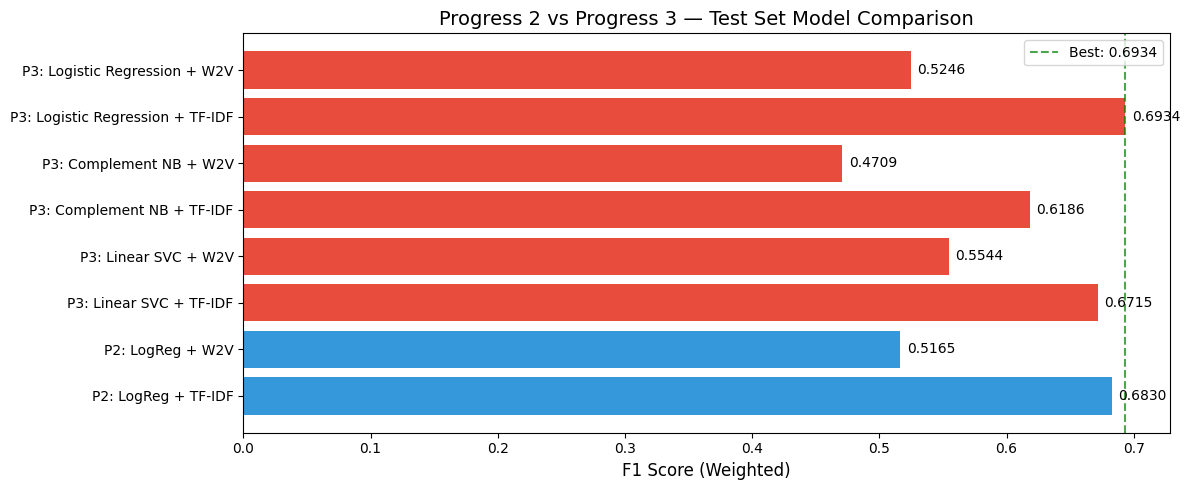

In [18]:
# Bar chart comparison on test set
fig, ax = plt.subplots(figsize=(12, 5))

test_model_names = list(results.keys())
test_f1_scores = [results[m]['f1_weighted'] for m in test_model_names]

colors = ['#3498db' if 'P2' in m else '#e74c3c' for m in test_model_names]
bars = ax.barh(test_model_names, test_f1_scores, color=colors)

ax.set_xlabel('F1 Score (Weighted)', fontsize=12)
ax.set_title('Progress 2 vs Progress 3 — Test Set Model Comparison', fontsize=14)
ax.axvline(
    x=max(test_f1_scores),
    color='green',
    linestyle='--',
    alpha=0.7,
    label=f'Best: {max(test_f1_scores):.4f}'
)

for bar, score in zip(bars, test_f1_scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

## 14. Best Model Analysis

In [19]:
# Find best P3 model
p3_results = {k: v for k, v in results.items() if 'P3' in k}
best_p3_name = max(p3_results, key=lambda x: p3_results[x]['f1_weighted'])
best_p3_metrics = p3_results[best_p3_name]

# Get predictions for best model
pred_mapping = {
    'P3: Linear SVC + TF-IDF': y_test_pred_svc_tfidf,
    'P3: Linear SVC + W2V': y_test_pred_svc_w2v,
    'P3: Complement NB + TF-IDF': y_test_pred_cnb_tfidf,
    'P3: Complement NB + W2V': y_test_pred_cnb_w2v,
    'P3: Logistic Regression + TF-IDF': y_test_pred_logreg_tfidf,
    'P3: Logistic Regression + W2V': y_test_pred_logreg_w2v,
}
best_pred = pred_mapping[best_p3_name]

print(f"  BEST PROGRESS 3 MODEL: {best_p3_name}")
print(f"\nTest Results:")
print(f"  Accuracy: {best_p3_metrics['accuracy']:.4f}")
print(f"  Precision: {best_p3_metrics['precision']:.4f}")
print(f"  Recall: {best_p3_metrics['recall']:.4f}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"  F1 (macro): {best_p3_metrics['f1_macro']:.4f}")
print("\n" + classification_report(y_test, best_pred, target_names=label_encoder.classes_))

  BEST PROGRESS 3 MODEL: P3: Logistic Regression + TF-IDF

Test Results:
  Accuracy: 0.6980
  Precision: 0.6913
  Recall: 0.6980
  F1 (weighted): 0.6934
  F1 (macro): 0.6999

                          precision    recall  f1-score   support

     appeal to authority       0.72      0.64      0.68        56
      appeal to majority       0.74      0.83      0.78        59
        appeal to nature       0.84      0.93      0.88        55
     appeal to tradition       0.72      0.78      0.75        59
appeal to worse problems       0.73      0.75      0.74        64
           false dilemma       0.70      0.76      0.73        50
    hasty generalization       0.42      0.32      0.36        60
                    none       0.68      0.68      0.68       317
          slippery slope       0.71      0.68      0.69        78

                accuracy                           0.70       798
               macro avg       0.70      0.71      0.70       798
            weighted avg       

In [20]:
# Per-class F1 for best model
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test, best_pred, average=None
)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
}).sort_values('F1-Score', ascending=False)

print(f"  PER-CLASS F1 SCORES — {best_p3_name}")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Support': '{:.0f}'
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  PER-CLASS F1 SCORES — P3: Logistic Regression + TF-IDF


,Class,Precision,Recall,F1-Score,Support
2,appeal to nature,0.8361,0.9273,0.8793,55
1,appeal to majority,0.7424,0.8305,0.7840,59
3,appeal to tradition,0.7188,0.7797,0.7480,59
4,appeal to worse problems,0.7273,0.7500,0.7385,64
5,false dilemma,0.7037,0.7600,0.7308,50
8,slippery slope,0.7067,0.6795,0.6928,78
7,none,0.6845,0.6845,0.6845,317
0,appeal to authority,0.7200,0.6429,0.6792,56
6,hasty generalization,0.4222,0.3167,0.3619,60


## 15. Confusion Matrices

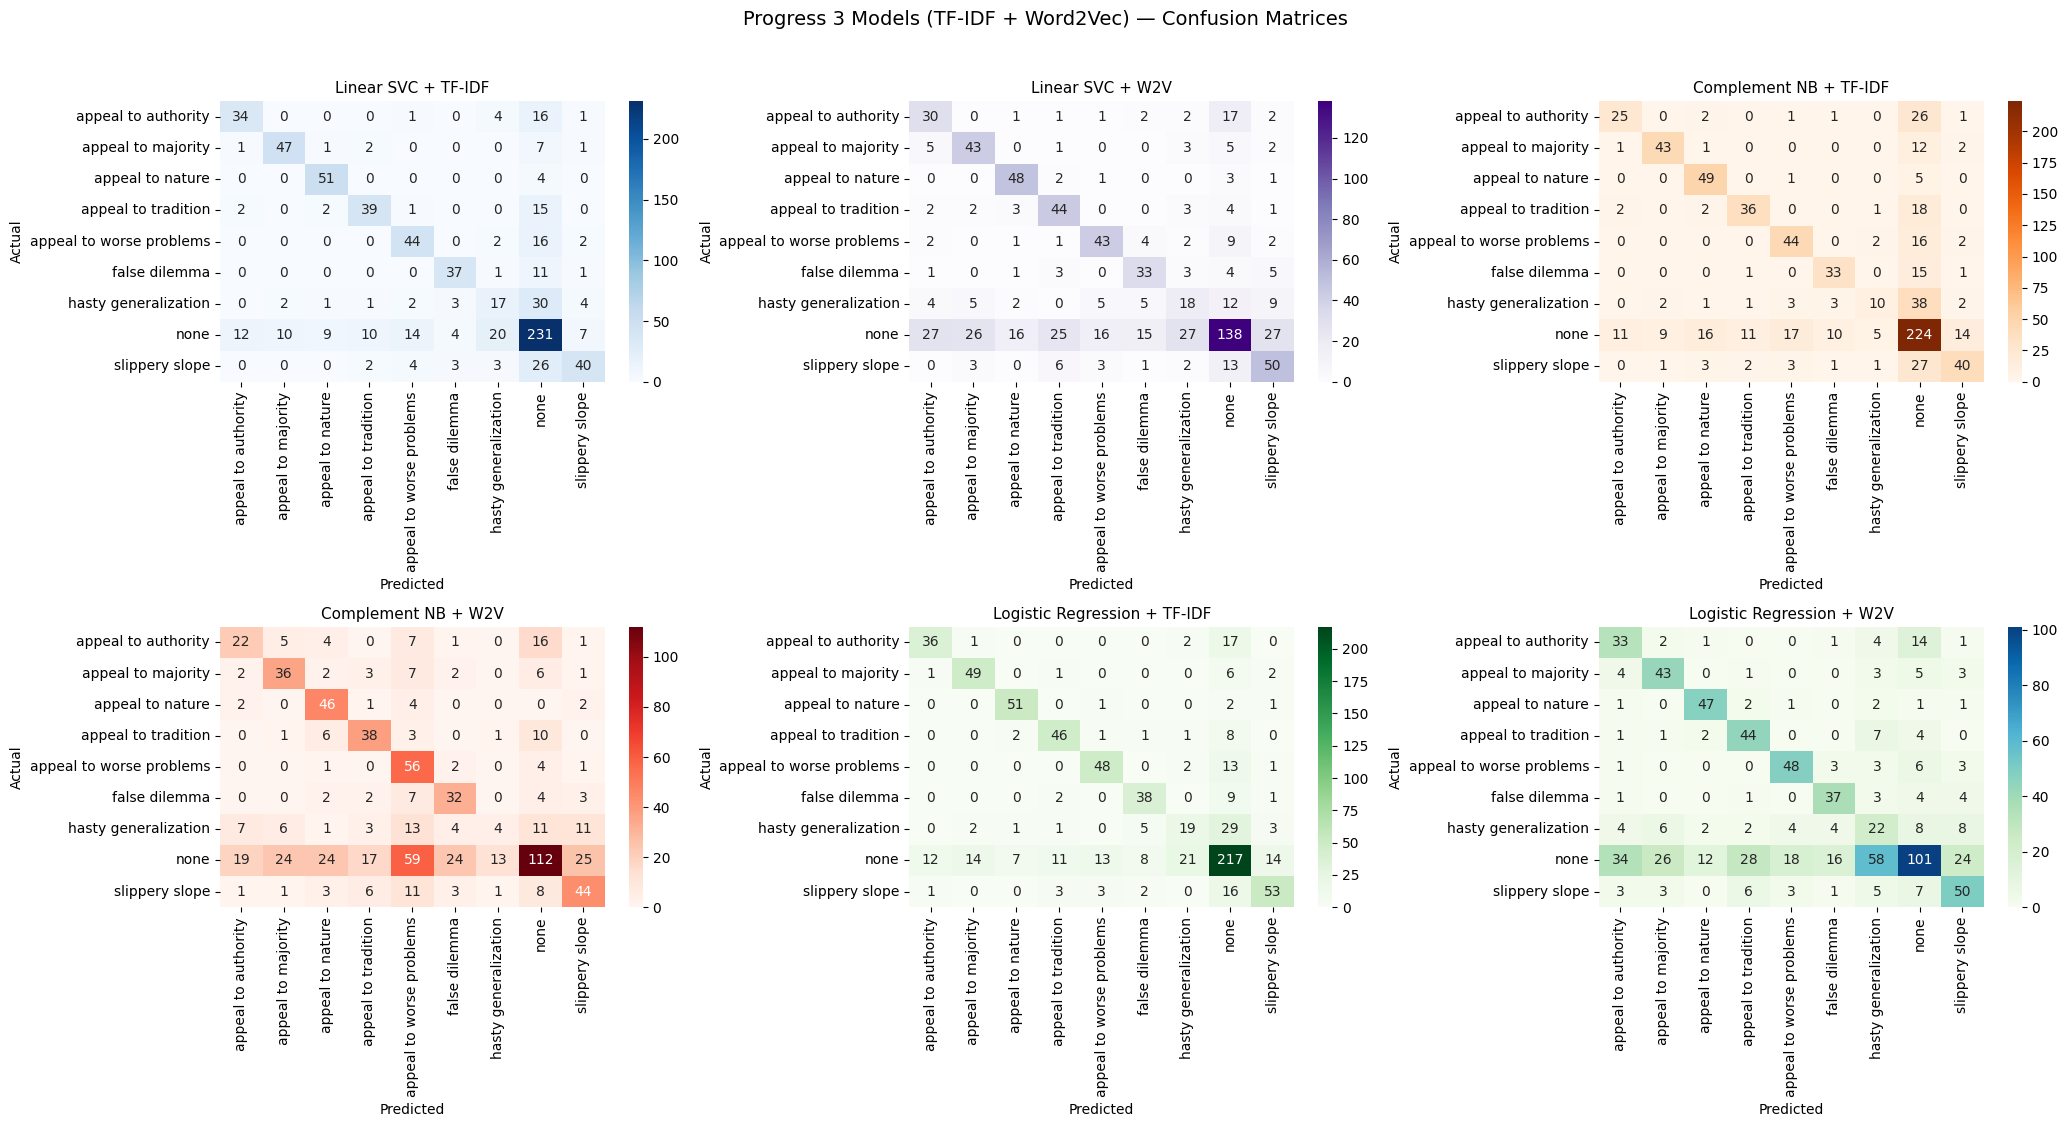

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(21, 11))

plot_items = [
    ('Linear SVC + TF-IDF', y_test_pred_svc_tfidf, 'Blues'),
    ('Linear SVC + W2V', y_test_pred_svc_w2v, 'Purples'),
    ('Complement NB + TF-IDF', y_test_pred_cnb_tfidf, 'Oranges'),
    ('Complement NB + W2V', y_test_pred_cnb_w2v, 'Reds'),
    ('Logistic Regression + TF-IDF', y_test_pred_logreg_tfidf, 'Greens'),
    ('Logistic Regression + W2V', y_test_pred_logreg_w2v, 'GnBu'),
]

for ax, (title, preds, cmap) in zip(axes.flatten(), plot_items):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Progress 3 Models (TF-IDF + Word2Vec) — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Save Models

In [22]:
os.makedirs('models/progress_3', exist_ok=True)

# Save all P3 models (TF-IDF + Word2Vec)
joblib.dump(model_svc_tfidf, 'models/progress_3/linear_svc_tfidf.joblib')
joblib.dump(model_cnb_tfidf, 'models/progress_3/complement_nb_tfidf.joblib')
joblib.dump(model_logreg_tfidf, 'models/progress_3/logistic_regression_tfidf.joblib')

joblib.dump(model_svc_w2v, 'models/progress_3/linear_svc_w2v.joblib')
joblib.dump(model_cnb_w2v, 'models/progress_3/complement_nb_w2v.joblib')
joblib.dump(model_logreg_w2v_p3, 'models/progress_3/logistic_regression_w2v.joblib')
joblib.dump(cnb_scaler, 'models/progress_3/cnb_w2v_scaler.joblib')

# Save vectorizers / embeddings and encoder
joblib.dump(tfidf_vectorizer, 'models/progress_3/tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer_logreg, 'models/progress_3/tfidf_vectorizer_logreg.joblib')
joblib.dump(w2v_model_p3, 'models/progress_3/word2vec_model.joblib')
joblib.dump(label_encoder, 'models/progress_3/label_encoder.joblib')

# Save results and setup info
p3_info = {
    'fallacy_indicators': list(fallacy_indicators),
    'feature_representations': {
        'svc_cnb_tfidf': 'word_1_2_12k',
        'logreg_tfidf': 'word_1_2_25k_relaxed',
        'word2vec': 'word2vec_100d_skipgram',
    },
    'model_params': {
        'linear_svc_tfidf': {'C': 3.0},
        'linear_svc_w2v': {'C': 1.0},
        'complement_nb_tfidf': {'alpha': 0.5},
        'complement_nb_w2v': {'alpha': 0.5, 'scaler': 'minmax_0_1'},
        'logistic_regression_tfidf': {'C': 4.0},
        'logistic_regression_w2v': {'C': 1.5},
    },
    'models': {k: v for k, v in results.items() if k.startswith('P3:')},
    'best_model': best_p3_name
}
joblib.dump(p3_info, 'models/progress_3/preprocessing_info.joblib')

print("All models saved to models/progress_3/")
print("\nSaved files:")
for f in sorted(os.listdir('models/progress_3')):
    print(f"  - {f}")

All models saved to models/progress_3/

Saved files:
  - cnb_w2v_scaler.joblib
  - complement_nb_tfidf.joblib
  - complement_nb_w2v.joblib
  - label_encoder.joblib
  - linear_svc_tfidf.joblib
  - linear_svc_w2v.joblib
  - logistic_regression_tfidf.joblib
  - logistic_regression_w2v.joblib
  - preprocessing_info.joblib
  - tfidf_vectorizer.joblib
  - tfidf_vectorizer_logreg.joblib
  - word2vec_model.joblib


## 17. Summary

In [23]:
print("  PROGRESS 3 SUMMARY")
print(f"\nModels: Linear SVC, Complement NB, Logistic Regression")
print(f"Representations per model: TF-IDF and Word2Vec (6 Progress 3 models total)")
print(f"TF-IDF setup (SVC/CNB): word_1_2_12k")
print(f"TF-IDF setup (LogReg): word_1_2_25k_relaxed")
print(f"Word2Vec setup: 100-dim skip-gram")
print(f"\nData Split:")
print(f"  Train: {len(df_train)} samples")
print(f"  Validation: {len(df_val)} samples")
print(f"  Test: {len(df_test)} samples")
print(f"\nTest Results (F1 Weighted):")
print(f"  {'Model':<42} {'F1':>10}")
print(f"  {'-'*58}")
for name, metrics in sorted(results.items(), key=lambda x: x[1]['f1_weighted'], reverse=True):
    print(f"  {name:<42} {metrics['f1_weighted']:>10.4f}")
print(f"\nBest Progress 3 Model: {best_p3_name}")
print(f"  Accuracy: {best_p3_metrics['accuracy']:.4f}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"\nModels saved to: models/progress_3/")

  PROGRESS 3 SUMMARY

Models: Linear SVC, Complement NB, Logistic Regression
Representations per model: TF-IDF and Word2Vec (6 Progress 3 models total)
TF-IDF setup (SVC/CNB): word_1_2_12k
TF-IDF setup (LogReg): word_1_2_25k_relaxed
Word2Vec setup: 100-dim skip-gram

Data Split:
  Train: 4564 samples
  Validation: 806 samples
  Test: 798 samples

Test Results (F1 Weighted):
  Model                                              F1
  ----------------------------------------------------------
  P3: Logistic Regression + TF-IDF               0.6934
  P2: LogReg + TF-IDF                            0.6830
  P3: Linear SVC + TF-IDF                        0.6715
  P3: Complement NB + TF-IDF                     0.6186
  P3: Linear SVC + W2V                           0.5544
  P3: Logistic Regression + W2V                  0.5246
  P2: LogReg + W2V                               0.5165
  P3: Complement NB + W2V                        0.4709

Best Progress 3 Model: P3: Logistic Regression + TF-IDF
 

---
## 18. Local Inference (Single Input)

Available models: svc_tfidf, cnb_tfidf, logreg_tfidf, svc_w2v, cnb_w2v, logreg_w2v

In [24]:
import joblib
import re
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Choose model: 'svc_tfidf', 'cnb_tfidf', 'logreg_tfidf', 'svc_w2v', 'cnb_w2v', or 'logreg_w2v'
MODEL_CHOICE = 'svc_tfidf'

model_files = {
    'svc_tfidf': 'models/progress_3/linear_svc_tfidf.joblib',
    'cnb_tfidf': 'models/progress_3/complement_nb_tfidf.joblib',
    'logreg_tfidf': 'models/progress_3/logistic_regression_tfidf.joblib',
    'svc_w2v': 'models/progress_3/linear_svc_w2v.joblib',
    'cnb_w2v': 'models/progress_3/complement_nb_w2v.joblib',
    'logreg_w2v': 'models/progress_3/logistic_regression_w2v.joblib',
}

if MODEL_CHOICE not in model_files:
    raise ValueError(f"Invalid MODEL_CHOICE: {MODEL_CHOICE}. Use one of {list(model_files.keys())}")

model = joblib.load(model_files[MODEL_CHOICE])
label_encoder = joblib.load('models/progress_3/label_encoder.joblib')
info = joblib.load('models/progress_3/preprocessing_info.joblib')
fallacy_indicators = set(info['fallacy_indicators'])

use_tfidf = MODEL_CHOICE.endswith('_tfidf')
if use_tfidf:
    if MODEL_CHOICE == 'logreg_tfidf':
        tfidf_vectorizer = joblib.load('models/progress_3/tfidf_vectorizer_logreg.joblib')
    else:
        tfidf_vectorizer = joblib.load('models/progress_3/tfidf_vectorizer.joblib')
    w2v_model = None
    cnb_scaler = None
else:
    tfidf_vectorizer = None
    w2v_model = joblib.load('models/progress_3/word2vec_model.joblib')
    cnb_scaler = joblib.load('models/progress_3/cnb_w2v_scaler.joblib') if MODEL_CHOICE == 'cnb_w2v' else None

stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]
    return tokens, ' '.join(tokens)

def document_vector_local(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

def predict_fallacy(text):
    tokens, processed = preprocess_text(text)
    if use_tfidf:
        features = tfidf_vectorizer.transform([processed])
    else:
        features = document_vector_local(tokens, w2v_model).reshape(1, -1)
        if MODEL_CHOICE == 'cnb_w2v':
            features = cnb_scaler.transform(features)

    prediction = model.predict(features)[0]
    return label_encoder.inverse_transform([prediction])[0]

# Test
test_text = "Everyone knows this is true. All experts agree."
result = predict_fallacy(test_text)
print(f"Model: {MODEL_CHOICE}")
print(f"Input: {test_text}")
print(f"Predicted fallacy: {result}")

Model: svc_tfidf
Input: Everyone knows this is true. All experts agree.
Predicted fallacy: appeal to authority
